In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from tensorflow.keras.utils import image_dataset_from_directory


## Data Preparation

In [10]:
training_set = image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)

Found 76515 files belonging to 4 classes.


In [11]:
validation_set = image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)

Found 21861 files belonging to 4 classes.


In [12]:
training_set

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [13]:
INPUT_SHAPE=(224,224,3)

In [14]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    
)

22661472/22661472 [==============================] - 19s 1us/step


In [15]:
model = tf.keras.models.Sequential()

In [16]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [17]:
model.add(mobnet)

In [18]:
model.add(tf.keras.layers.Dense(units = 4,activation="softmax"))

In [19]:
metrics_list = ["accuracy",tf.keras.metrics.F1Score()]

In [20]:
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=metrics_list)

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Function  (None, 1000)              5507432   
 al)                                                             
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5511436 (21.02 MB)
Trainable params: 5487036 (20.93 MB)
Non-trainable params: 24400 (95.31 KB)
_________________________________________________________________


In [30]:
tranning_history = model.fit(x=training_set,validation_data=validation_set,epochs=15, batch_size=4)

Epoch 1/15
2392/2392 [==============================] - 7398s 3s/step - loss: 0.0923 - accuracy: 0.9862 - f1_score: 0.9759 - val_loss: 0.1365 - val_accuracy: 0.9699 - val_f1_score: 0.9477
Epoch 2/15
2392/2392 [==============================] - 7556s 3s/step - loss: 0.0786 - accuracy: 0.9875 - f1_score: 0.9783 - val_loss: 0.1293 - val_accuracy: 0.9715 - val_f1_score: 0.9507
Epoch 3/15
2392/2392 [==============================] - 8998s 4s/step - loss: 0.0679 - accuracy: 0.9890 - f1_score: 0.9808 - val_loss: 0.1151 - val_accuracy: 0.9740 - val_f1_score: 0.9540
Epoch 4/15
2392/2392 [==============================] - 7558s 3s/step - loss: 0.0595 - accuracy: 0.9904 - f1_score: 0.9833 - val_loss: 0.1115 - val_accuracy: 0.9746 - val_f1_score: 0.9557
Epoch 5/15
2392/2392 [==============================] - 7429s 3s/step - loss: 0.0541 - accuracy: 0.9912 - f1_score: 0.9846 - val_loss: 0.1385 - val_accuracy: 0.9690 - val_f1_score: 0.9464
Epoch 6/15
2392/2392 [==============================] - 8507

In [33]:
model.save("./Trained_eye_disease_model.h5")
model.save("./Trained_eye_disease_model.keras")

In [36]:
tranning_history.history

{'loss': [0.09232110530138016,
  0.07856318354606628,
  0.06793802231550217,
  0.05947152152657509,
  0.05414750799536705,
  0.053046729415655136,
  0.04682079702615738,
  0.044641029089689255,
  0.040649279952049255,
  0.03802753612399101,
  0.036202795803546906,
  0.03310403227806091,
  0.03146769106388092,
  0.03174293413758278,
  0.030838724225759506],
 'accuracy': [0.9861987829208374,
  0.9874665141105652,
  0.9889825582504272,
  0.9903548359870911,
  0.9911651015281677,
  0.9907207489013672,
  0.9920276999473572,
  0.9922237396240234,
  0.9929686784744263,
  0.9932301044464111,
  0.9933869242668152,
  0.9938835501670837,
  0.9942886829376221,
  0.9937920570373535,
  0.9938835501670837],
 'f1_score': [array([0.9886594, 0.9804649, 0.9407979, 0.9935317], dtype=float32),
  array([0.9892678 , 0.98222435, 0.94737685, 0.994265  ], dtype=float32),
  array([0.99028575, 0.984127  , 0.95348275, 0.9952636 ], dtype=float32),
  array([0.99211574, 0.9864063 , 0.9592739 , 0.99533427], dtype=floa

In [37]:
#Saving history
with open("tranning_history.pkl","wb") as f:
    pickle.dump(tranning_history.history,f)

In [38]:
#Reloading History from pickle
with open('tranning_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'loss': [0.09232110530138016,
  0.07856318354606628,
  0.06793802231550217,
  0.05947152152657509,
  0.05414750799536705,
  0.053046729415655136,
  0.04682079702615738,
  0.044641029089689255,
  0.040649279952049255,
  0.03802753612399101,
  0.036202795803546906,
  0.03310403227806091,
  0.03146769106388092,
  0.03174293413758278,
  0.030838724225759506],
 'accuracy': [0.9861987829208374,
  0.9874665141105652,
  0.9889825582504272,
  0.9903548359870911,
  0.9911651015281677,
  0.9907207489013672,
  0.9920276999473572,
  0.9922237396240234,
  0.9929686784744263,
  0.9932301044464111,
  0.9933869242668152,
  0.9938835501670837,
  0.9942886829376221,
  0.9937920570373535,
  0.9938835501670837],
 'f1_score': [array([0.9886594, 0.9804649, 0.9407979, 0.9935317], dtype=float32),
  array([0.9892678 , 0.98222435, 0.94737685, 0.994265  ], dtype=float32),
  array([0.99028575, 0.984127  , 0.95348275, 0.9952636 ], dtype=float32),
  array([0.99211574, 0.9864063 , 0.9592739 , 0.99533427], dtype=floa

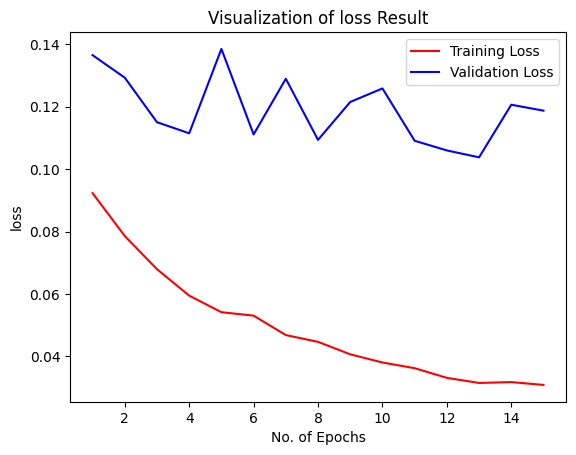

In [40]:
#loss visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.ylabel("loss")
plt.title('Visualization of loss Result')
plt.legend()
plt.show()

## Model Evaluation

In [41]:
model = tf.keras.models.load_model("Trained_eye_disease_model.h5")

In [50]:
test_set =  image_dataset_from_directory(
    './test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [51]:
test_loss,test_acc,f1_score=model.evaluate(test_set)

171/171 [==============================] - 194s 1s/step - loss: 0.1241 - accuracy: 0.9716 - f1_score: 0.9491


In [52]:
test_loss,test_acc,f1_score

(0.12414837628602982,
 0.9715539813041687,
 array([0.97553194, 0.9598953 , 0.873455  , 0.98734665], dtype=float32))

In [53]:
#COmputing true label from test set 
true_categories = tf.concat([y for x,y in test_set],axis =0)
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [54]:
Y_true = tf.argmax(true_categories,axis=1)

In [55]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [56]:
#Computing Prediccted labels using test_set
predicted_categories = model.predict(test_set)
predicted_categories

171/171 [==============================] - 192s 1s/step


array([[9.9456006e-01, 1.6800463e-03, 2.4893468e-03, 1.2705333e-03],
       [9.9439740e-01, 1.7123501e-03, 2.5874684e-03, 1.3027525e-03],
       [9.9456584e-01, 1.6786180e-03, 2.4861775e-03, 1.2693515e-03],
       ...,
       [4.6253990e-04, 1.3431545e-03, 1.9866074e-03, 9.9620771e-01],
       [4.6212837e-04, 1.3423889e-03, 1.9843290e-03, 9.9621117e-01],
       [4.6212881e-04, 1.3423902e-03, 1.9843308e-03, 9.9621117e-01]],
      dtype=float32)

In [57]:
Y_Pred = tf.argmax(predicted_categories,axis=1)
Y_Pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

## 1.Classification Report

In [61]:
from sklearn.metrics import classification_report
print(classification_report(Y_true, Y_Pred))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3746
           1       0.97      0.95      0.96      1161
           2       0.91      0.84      0.87       887
           3       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.96      0.94      0.95     10933
weighted avg       0.97      0.97      0.97     10933



## 2. Confusion Matrix

In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_Pred)
cm


array([[3668,   17,   53,    8],
       [  18, 1101,    2,   40],
       [  84,    6,  742,   55],
       [   4,    9,   15, 5111]], dtype=int64)

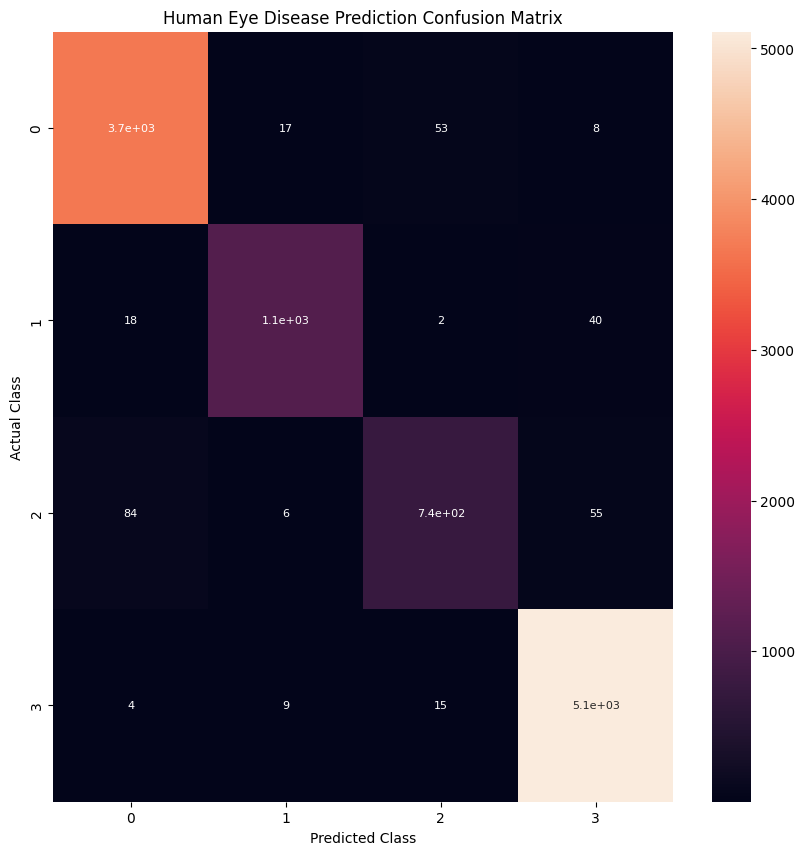

In [63]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix", fontsize=12 )
plt.show()